In [1]:
import pandas as pd
import zipfile
import io
import sys, os
from pathlib import Path
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm
project_root = "/home/shuol/ls_learnqf"
if project_root not in sys.path:
    sys.path.append(project_root)
from util import *
from stock_pool import *
import tushare as ts
import time
import pickle

经验证据表明，低波动股票收益表现往往优于高波动股票，股票收益与波动之间存在着负相关性。为了检验A股市场的低波动异象，选取振幅因子作为波动类因子的代理变量。\
为了进一步分析振幅因子的信息结构，引入价格维度。预期在不同价格位置，振幅分布所蕴含的信息会存在结构性差异。

回测区间为2010年4月30日至2020年4月30日；样本空间为全体A股，剔除ST股和上市未满60 日的新股；每月月初调仓，持仓一个自然月，交易费率千分之三。

In [2]:
# 初始化pro接口
pro = ts.pro_api('0afffc3e8d0c5d2d2478e749ee179c10c3efddac434f4dd953f57730')

# 获取回测区间的样本空间 
universe_df = get_history_sample_space_df(pro=pro,start_date='20100430', end_date='20200430', pool_type='ALL', 
                                          include_bj=False, min_list_days=60, freq='M', sleep_interval=0.1)

#获取股票池的历史日行情数据
price_df = get_daily_price_for_universe(pro=pro, universe_df=universe_df,start_date='20100301', end_date='20200430',
                                        fields='ts_code,trade_date,open,high,low,close,pre_close,vol,amount')

#整理df
price_df['trade_date'] = pd.to_datetime(price_df['trade_date'])
panel_df = price_df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)

下载区间日频行情:  35%|████████████████████▌                                      | 1247/3570 [23:55<2:48:15,  4.35s/it]

请求 002241.SZ 数据时发生错误: HTTPConnectionPool(host='api.waditu.com', port=80): Read timed out. (read timeout=30)


下载区间日频行情:  87%|█████████████████████████████████████████████████████▏       | 3110/3570 [55:52<09:18,  1.21s/it]

请求 300690.SZ 数据时发生错误: HTTPConnectionPool(host='api.waditu.com', port=80): Read timed out.


下载区间日频行情: 100%|███████████████████████████████████████████████████████████| 3570/3570 [1:01:39<00:00,  1.04s/it]


In [5]:
panel_df

,ts_code,trade_date,open,high,low,close,pre_close,vol,amount
0,000001.SZ,2010-03-02,22.89,23.96,22.89,23.11,22.45,684647.27,1.599220e+06
1,000001.SZ,2010-03-03,23.11,23.35,22.80,23.30,23.11,284111.39,6.554447e+05
2,000001.SZ,2010-03-04,23.32,23.63,23.00,23.10,23.30,376320.84,8.773898e+05
3,000001.SZ,2010-03-05,23.10,23.49,23.05,23.27,23.10,291842.10,6.811939e+05
4,000001.SZ,2010-03-08,23.32,24.05,23.06,23.85,23.27,441053.92,1.045699e+06
...,...,...,...,...,...,...,...,...,...
6078139,688399.SH,2020-04-24,150.00,153.00,138.08,144.08,128.88,46408.37,6.756643e+05
6078140,688399.SH,2020-04-27,135.00,140.00,126.00,126.20,144.08,35730.24,4.691092e+05
6078141,688399.SH,2020-04-28,123.20,134.99,121.76,127.60,126.20,26022.02,3.358797e+05
6078142,688399.SH,2020-04-29,128.83,131.00,117.78,118.00,127.60,27430.22,3.349412e+05


**振幅因子** ：回看最近20个交易日，计算股票每日的振幅（最高价/最低价-1），取其均值作为振幅因子。\
\
价格维度下的振幅因子切割方案：
1. 数据回溯  
   对选定股票 $ S $，回溯获取其最近 $N$ 个交易日的数据（研报里 $N = 20$）。
2. 振幅计算
   计算股票 $ S $每日的振幅：
   $
   \text{振幅} = \frac{\text{最高价}}{\text{最低价}} - 1
   $
3. 高价振幅因子 $V_{\text{high}}(\lambda)$
   选择收盘价较高的前 $\lambda $（例如 40%）的有效交易日，计算这些交易日振幅的均值，得到高价振幅因子：
   $
   V_{\text{high}}(\lambda)
   $
4. 低价振幅因子 $ V_{\text{low}}(\lambda) $
   选择收盘价较低的前 $\lambda $（例如 40%）的有效交易日，计算这些交易日振幅的均值，得到低价振幅因子：
   $
   V_{\text{low}}(\lambda)
   $

In [12]:
def calculate_amplitude_factors(daily_data: pd.DataFrame, N: int = 20, lambda_ratio: float = 0.4) -> pd.DataFrame:
    """
    计算价格维度下的振幅因子
    """
    df = daily_data.sort_values(['ticker', 'date']).copy()
    df['amp'] = df['high'] / df['low'] - 1.0

    def rolling_slice(group):
        close = group['close'].values
        amp = group['amp'].values
        n = len(group)
        
        v_high = np.full(n, np.nan)
        v_low = np.full(n, np.nan)

        if n >= int(N * 0.5):
            for i in range(N - 1, n):
                window_close = close[i - N + 1 : i + 1]
                window_amp = amp[i - N + 1 : i + 1]
                
                # 过滤停牌导致的 NaN
                valid_mask = ~np.isnan(window_close) & ~np.isnan(window_amp)
                w_c = window_close[valid_mask]
                w_a = window_amp[valid_mask]
                
                if len(w_c) < int(N * 0.5):
                    continue
                    
                # 计算需要截取的天数 k 
                k = max(1, int(np.round(len(w_c) * lambda_ratio)))
                
                # 按收盘价从小到大排序的索引
                sort_idx = np.argsort(w_c)
                
                # 低价区振幅均值 V_low
                v_low[i] = np.mean(w_a[sort_idx[:k]])
                # 高价区振幅均值 V_high
                v_high[i] = np.mean(w_a[sort_idx[-k:]])

        return pd.DataFrame({'V_high': v_high, 'V_low': v_low}, index=group.index)

    # 运用 groupby 计算并把结果拼回原表
    res = df.groupby('ticker', group_keys=False).apply(rolling_slice)
    df['V_high'] = res['V_high']
    df['V_low'] = res['V_low']
    return df

In [13]:
# 因子计算 & 提取月末(月初前一天)截面对齐自然月收益

df_clean = panel_df.copy()
df_clean['trade_date'] = pd.to_datetime(df_clean['trade_date'])

# 确保数据排
df_clean = df_clean.sort_values(['ts_code', 'trade_date'])

# 提取月末截面
df_clean['year_month'] = df_clean['trade_date'].dt.to_period('M')
# 以 ts_code 和 月份分组，取每月最后一天
df_monthly = df_clean.groupby(['ts_code', 'year_month']).last().reset_index()

#计算未来一个月收益率 (下个月月末收盘价 / 本月月末收盘价 - 1)
df_monthly['next_ret_1m'] = df_monthly.groupby('ts_code')['close'].shift(-1) / df_monthly['close'] - 1

# 剔除最后一行（因为没有未来收益率）
df_monthly = df_monthly.dropna(subset=['next_ret_1m']).copy()

In [14]:
# 定义要测试的 lambda 比例
lambda_list = [0.2, 0.4, 0.6, 0.8, 1]

# 用于存储不同 lambda 下的结果
results_v_high = {}
results_v_low = {}
group_returns_dict = {}

df_for_calc = df_clean.rename(columns={'ts_code': 'ticker', 'trade_date': 'date'})

for lam in lambda_list:
    
    # 计算因子
    df_factor_raw = calculate_amplitude_factors(df_for_calc, N=20, lambda_ratio=lam)
    
    # 还原回原始列名以便合并
    df_factor_raw = df_factor_raw.rename(columns={'ticker': 'ts_code', 'date': 'trade_date'})
    
    # 合并
    temp_df = pd.merge(
        df_monthly[['ts_code', 'trade_date', 'next_ret_1m']], 
        df_factor_raw[['ts_code', 'trade_date', 'V_high', 'V_low']], 
        on=['ts_code', 'trade_date'], how='inner')
    
    # 计算 IC 
    ic_high = temp_df.groupby('trade_date').apply(lambda x: x['V_high'].corr(x['next_ret_1m'], method='spearman'))
    ic_low = temp_df.groupby('trade_date').apply(lambda x: x['V_low'].corr(x['next_ret_1m'], method='spearman'))
    
    # 计算 V_high 分组收益 (费率 3‰)
    group_ret_high = calc_long_short_returns(temp_df, 'V_high', 'next_ret_1m', date_col='trade_date', q=5, fee_rate=0.003)
    
    # 结果存储
    results_v_high[lam] = {'IC_Mean': ic_high.mean(),'ICIR': (ic_high.mean() / (ic_high.std() + 1e-12)) * np.sqrt(12),
                           'Long_Short_Nav': (1 + group_ret_high['Long_Short'].fillna(0)).cumprod()}
    results_v_low[lam] = {'IC_Mean': ic_low.mean(),'ICIR': (ic_low.mean() / (ic_low.std() + 1e-12)) * np.sqrt(12)}
    group_returns_dict[lam] = group_ret_high

因子绩效指标可视化

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

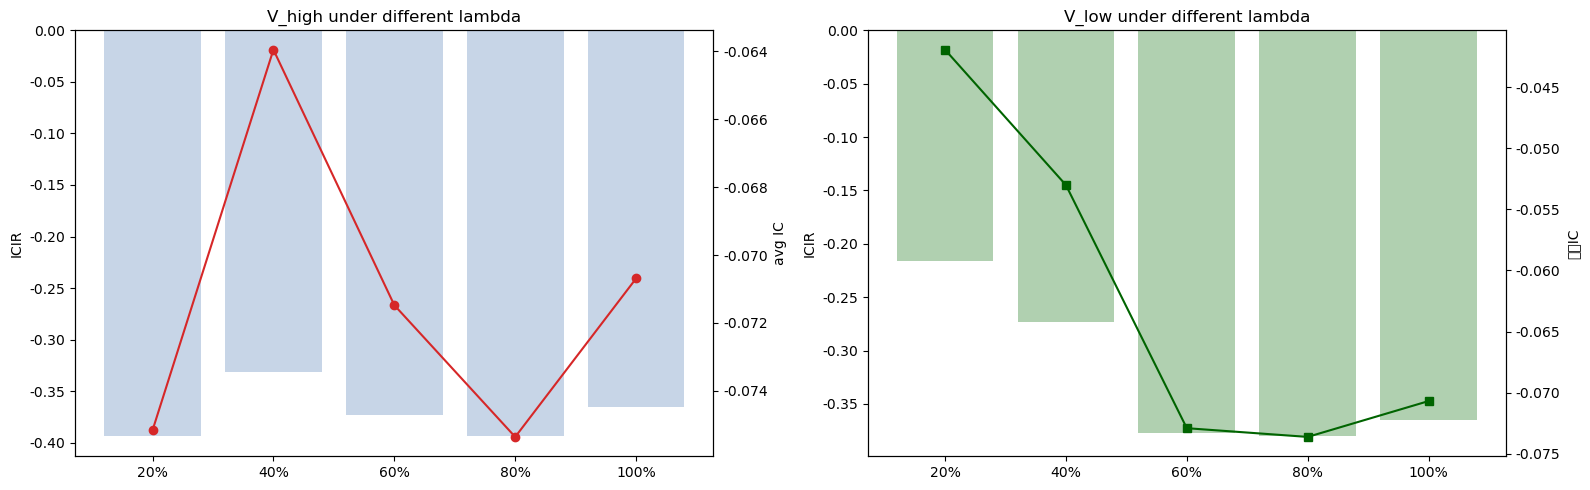

In [19]:
lambdas_str = [f"{int(l*100)}%" for l in lambda_list]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 子图1: V_high 绩效
ax1 = axes[0]
ax1.bar(lambdas_str, [results_v_high[l]['ICIR'] for l in lambda_list], color='lightsteelblue', alpha=0.7)
ax1.set_ylabel('ICIR')
ax1_t = ax1.twinx()
ax1_t.plot(lambdas_str, [results_v_high[l]['IC_Mean'] for l in lambda_list], color='tab:red', marker='o')
ax1_t.set_ylabel('avg IC')
ax1.set_title('V_high under different lambda')

# 子图2: V_low 绩效 
ax2 = axes[1]
ax2.bar(lambdas_str, [results_v_low[l]['ICIR'] for l in lambda_list], color='darkseagreen', alpha=0.7)
ax2.set_ylabel('ICIR')
ax2_t = ax2.twinx()
ax2_t.plot(lambdas_str, [results_v_low[l]['IC_Mean'] for l in lambda_list], color='darkgreen', marker='s')
ax2_t.set_ylabel('平均IC')
ax2.set_title('V_low under different lambda')

plt.tight_layout()
plt.show()

/home/shuol/ls_learnqf/util.py:218: RuntimeWarning: invalid value encountered in scalar power
  ann_ret = nav ** (252 / n) - 1
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 

λ=20% 指标: {'年化收益率': 'nan%', '年化波动率': '444.24%', '最大回撤': '-100.08%', '夏普比率': '-2.37'}
λ=40% 指标: {'年化收益率': 'nan%', '年化波动率': '453.55%', '最大回撤': '-103.09%', '夏普比率': '-2.07'}
λ=60% 指标: {'年化收益率': 'nan%', '年化波动率': '430.18%', '最大回撤': '-101.51%', '夏普比率': '-2.12'}
λ=80% 指标: {'年化收益率': '-100.00%', '年化波动率': '502.14%', '最大回撤': '-100.95%', '夏普比率': '-1.40'}
λ=100% 指标: {'年化收益率': '-100.00%', '年化波动率': '491.10%', '最大回撤': '-102.06%', '夏普比率': '-0.94'}


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

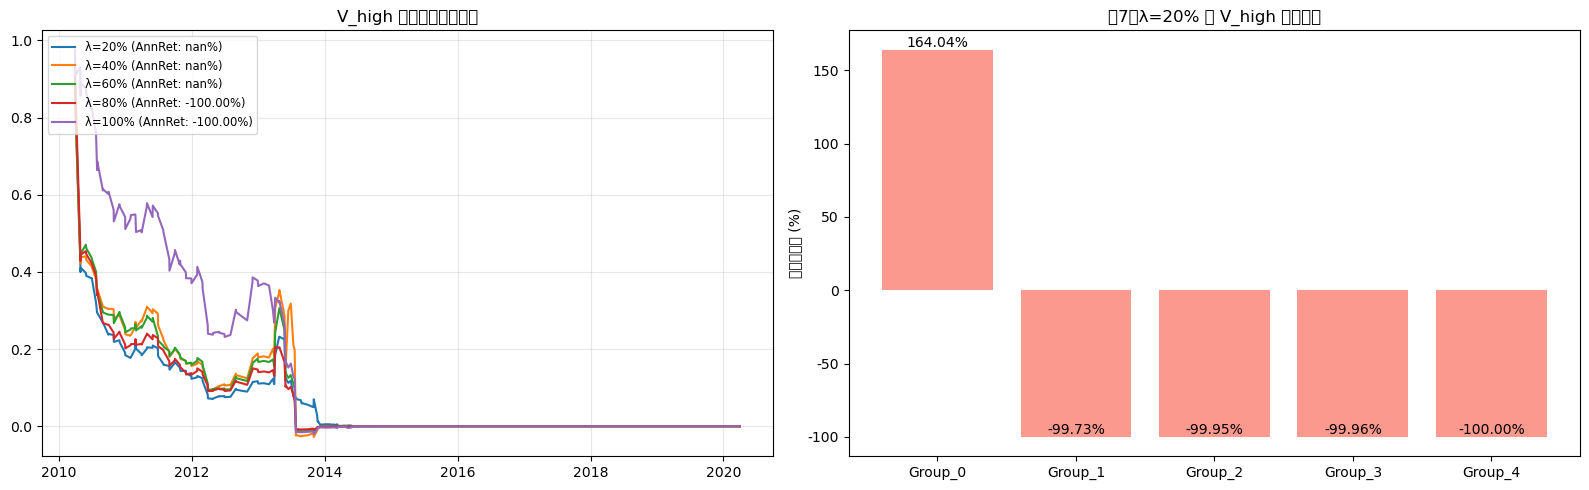

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# --- 左图：V_high 多空对冲净值表现 ---
ax3 = axes[0]
for lam in lambda_list:
    # 获取多空收益序列
    ls_ret = group_returns_dict[lam]['Long_Short'].fillna(0)
    # 计算累计净值
    nav = (1 + ls_ret).cumprod()
    
    #核心指标，lambda 对结果的影响
    metrics = get_metrics(ls_ret)
    print(f"λ={int(lam*100)}% 指标: {metrics.to_dict()}")
    
    ax3.plot(nav, label=f"λ={int(lam*100)}% (AnnRet: {metrics['年化收益率']})")

ax3.set_title('V_high 多空对冲净值表现')
ax3.legend(loc='upper left', fontsize='small')
ax3.grid(alpha=0.3)

# --- 右图：λ=20% 时 V_high 5分组年化收益率  ---
ax4 = axes[1]
target_lam = 0.2
df_res = group_returns_dict[target_lam]
group_cols = [f'Group_{i}' for i in range(5)]

# get_metrics 提取年化收益率
ann_rets_from_metrics = []
for g in group_cols:
    m = get_metrics(df_res[g])
    # 提取字符串中的数字 
    val = float(m['年化收益率'].replace('%', ''))
    ann_rets_from_metrics.append(val)

bars = ax4.bar(group_cols, ann_rets_from_metrics, color='salmon', alpha=0.8)
ax4.set_title(f'图7：λ={int(target_lam*100)}% 时 V_high 分组年化')
ax4.set_ylabel('年化收益率 (%)')

for b in bars:
    h = b.get_height()
    ax4.text(b.get_x() + b.get_width()/2., h, f'{h:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

高价振幅因子具有更强的负向选股能力, 但年化波动率和最大回撤也相对较高。\
为了提升高价振幅因子$V_{\text{high}}$ 的选股稳定性，考虑在横截面上对高价振幅因子进行标准化处理。\
这里标准化的做法是：在同一切割比例$\lambda$下，我们将高价振幅
因子$V_{\text{high}}$ 与低价振幅因子$V_{\text{low}}$ 作差，构造得到**理想振幅因子$V$**，表达式如下：
$$V(\lambda) = V_{\text{high}}(\lambda) - V_{\text{low}}(\lambda)$$

理想振幅因子的选股能力要显著优于高价振幅因子。现在进一步因子测评。\
对理想振幅因子进行行业风格中性化：剔除行业和主要风格因子（市值、动量、波动率、流动性、Beta）。

考察理想振幅因子对参数回看天数$N$的敏感性

不同样本空间：沪深300、中证500、中证1000。

振幅和换手率都是反映股票成交活跃程度的指标。换手率因子是否也具有同样的隐藏结构？\
使用过去20日换手率均值代表换手率因子，应用理想振幅因子的构造框架构造理想换手率因子。

In [21]:
panel_df

,ts_code,trade_date,open,high,low,close,pre_close,vol,amount
0,000001.SZ,2010-03-02,22.89,23.96,22.89,23.11,22.45,684647.27,1.599220e+06
1,000001.SZ,2010-03-03,23.11,23.35,22.80,23.30,23.11,284111.39,6.554447e+05
2,000001.SZ,2010-03-04,23.32,23.63,23.00,23.10,23.30,376320.84,8.773898e+05
3,000001.SZ,2010-03-05,23.10,23.49,23.05,23.27,23.10,291842.10,6.811939e+05
4,000001.SZ,2010-03-08,23.32,24.05,23.06,23.85,23.27,441053.92,1.045699e+06
...,...,...,...,...,...,...,...,...,...
6078139,688399.SH,2020-04-24,150.00,153.00,138.08,144.08,128.88,46408.37,6.756643e+05
6078140,688399.SH,2020-04-27,135.00,140.00,126.00,126.20,144.08,35730.24,4.691092e+05
6078141,688399.SH,2020-04-28,123.20,134.99,121.76,127.60,126.20,26022.02,3.358797e+05
6078142,688399.SH,2020-04-29,128.83,131.00,117.78,118.00,127.60,27430.22,3.349412e+05


In [25]:
panel_df.to_pickle("panel_df.pkl")

In [ ]:
# panel_df = pd.read_pickle("panel_df.pkl")